# 14th video. 자료구조: 바이너리 인덱스 트리(Binary Indexed Tree, BIT, 펜윅 트리) 10분 정복

## 0. 목차
1. 데이터 업데이트가 가능한 상황에서의 구간 합 (Interval Sum) 문제
2. 바이너리 인덱스 트리 (Binary Indexed Tree)
3. 바이너리 인덱스 트리: 트리 구조 만들기
4. 바이너리 인덱스 트리: 업데이트
5. 바이너리 인덱스 트리: 누적 합(Prefix Sum)
6. 바이너리 인덱스 트리 구현: 파이썬
7. 정리 및 회고

## 1. 데이터 업데이트가 가능한 상황에서의 구간 합 (Interval Sum) 문제

- BOJ '구간 합 구하기' 문제 : https://www.acmicps.net/problem/2042

- 어떤 N개의 수가 주어져 있다. 그런데 중간에 수의 변경이 빈번히 일어나고 그 중간에 어떤 부분의 합을 구하려 한다. 만약에 1, 2, 3, 4, 5라는 수가 있고, 3번째 수를 6으로 바꾸고 2번째부터 5번째까지 합을 구하라고 한다면 17을 출력하면 되는 것이다. 그리고 그 상태에서 다섯 번째 수를 2로 바꾸고 3번째부터 5번째까지 합을 구하락 한다면 12가 될 것이다.

- 데이터 개수 : N (1 $\le$ N $\le$ 1,000,000) 
- 데이터 변경 횟수 : M (1 $\le$ M $\le$ 10,000) 
- 구간 합 계산 횟수 : K (1 $\le$ K $\le$ 10,000) 

## 2. 바이너리 인덱스 트리 (Binary Indexed Tree)

- 바이너리 인덱스 트리(binary indexed tree)는 2진법 인덱스 구조를 활용해 구간 합 문제를 효과적으로 해결해 줄 수 있는 자료구조를 의미한다.
    - 펜윅 트리(fenwick tree)라고도 한다.

- 정수에 따른 2진수 표기

|정수|2진수 표기|
|:--:|:--:|
|7|00000000 00000000 00000000 0000111|
|-7| 11111111 11111111 11111111 1111001|

- 0이 아닌 마지막 비트를 찾는 방법
    - 특정한 숫자 K의 0이 아닌 마지막 비트를 찾기 위해서 K & -K를 계산하면 된다.

- K & -K 계산 결과 예시

| 정수 K | 2진수 표기 | K & -K |
| :---: | :--- | :---: |
| 0 | 00000000 00000000 00000000 00000000 | 0 |
| 1 | 00000000 00000000 00000000 00000001 | 1 |
| 2 | 00000000 00000000 00000000 00000010 | 2 |
| 3 | 00000000 00000000 00000000 00000011 | 1 |
| 4 | 00000000 00000000 00000000 00000100 | 4 |
| 5 | 00000000 00000000 00000000 00000101 | 1 |
| 6 | 00000000 00000000 00000000 00000110 | 2 |
| 7 | 00000000 00000000 00000000 00000111 | 1 |
| 8 | 00000000 00000000 00000000 00001000 | 8 |

- python에서는 & 연산을 수행하면 자동으로 특정 정수를 2의 보수로 표기한 결과에서의 비트 단위 &연산을 수행할 수 있다.
```python
n = 8
for i in range(n+1):
    print(i, "의 마지막 비트", (i & -i))
```

## 3. 바이너리 인덱스 트리: 트리 구조 만들기

- 트리 구조 만들기: 0이 아닌 마짐가 비트 = 내가 저장하고 있는 값들의 개수

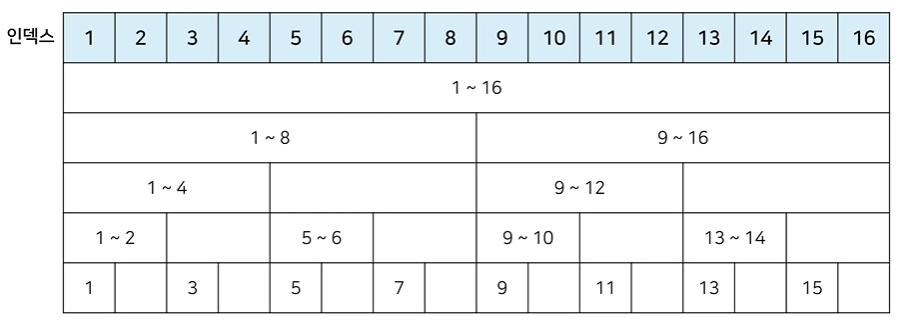

## 4. 바이너리 인덱스 트리: 업데이트

- 특정 값을 변경할 때: 0이 아닌 마지막 비트만큼 더하면서 구간들의 값을 변경 (예시 = 3rd)
    - 3번째와 3번째 값을 포함하는 4, 8, 16번째 값을 변경해야 한다.
    - 인덱스가 N일 때 표의 높이가 $O(\log N)$이므로 특정 값을 변경할 때, 최악의 경우에도 $O(\log N)$의 시간 복잡도를 보장할 수 있다.
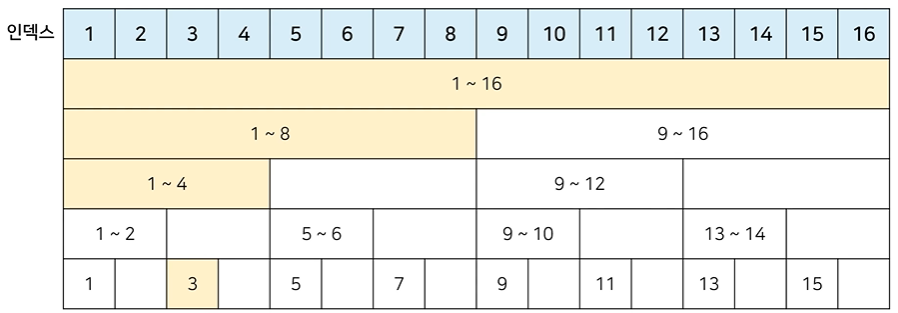

## 5. 바이너리 인덱스 트리: 누적 합(Prefix Sum)

- 1부터 N까지의 합(누적 합) 구하기: 0이 아닌 마지막 비트만큼 빼면서 구간들의 값의 합 계산 (예시 = 11th)

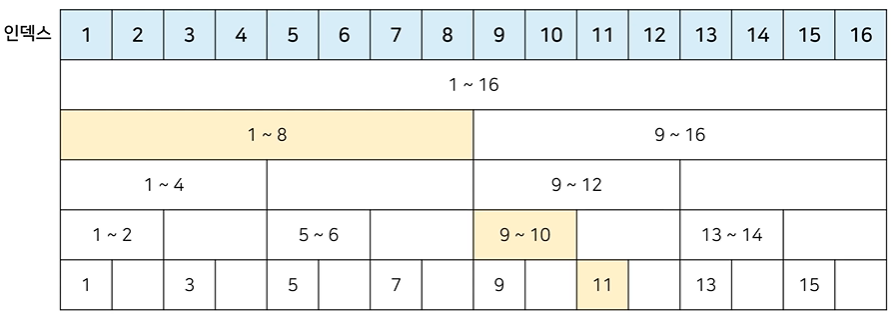

## 6. 바이너리 인덱스 트리 구현: 파이썬

```python
import sys
input = sys.stdin.readline

# 데이터의 개수(n), 변경 횟수(m), 구간 합 계산 횟수(k)
n, m, k = map(int, input().split())

# 전체 데이터의 개수는 최대 1,000,000개
arr = [0] * (n+1)
tree = [0] * (n+1)

# i번째 수까지의 누적 합을 계산하는 함수
def prefix_sum(i):
    result = 0
    while i > 0:
        result += tree[i]
        # 0이 아닌 마지막 비트만큼 빼가면서 이동
        i -= (i & -i)
    return result

# i번째 수를 dif만큼 더하는 함수
def update(i, dif):
    while i <= n:
        tree[i] += dif
        i += (i & -i)

# start부터 end까지의 구간 합을 계산하는 함수
def interval_sum(start, end):
    return prefix_sum(end) - prefix_sum(start - 1)

for i in range(1, n+1):
    x = int(input())
    arr[i] = x
    update(i, x)

for i in range(m + k):
    a, b, c = map(int, input().split())
    # 업데이트 연산인 경우
    if a == 1:
        update(x, c - arr[b]) # 바뀐 크기(dif)만큼 적용
        arr[b] = c
    # 구간 합 연산인 경우
    else:
        print(interval_sum(b, c))
```

## 7. 정리 및 회고

### 순서
1. 데이터 업데이트가 가능한 상황에서의 구간 합 (Interval Sum) 문제
2. 바이너리 인덱스 트리 (Binary Indexed Tree)
3. 바이너리 인덱스 트리: 트리 구조 만들기
4. 바이너리 인덱스 트리: 업데이트
5. 바이너리 인덱스 트리: 누적 합(Prefix Sum)
6. 바이너리 인덱스 트리 구현: 파이썬
7. 정리 및 회고

### 키워드
바이너리 인덱스 트리, 누적 합

### 회고
1. 이번 강의도 구현 연습 안하고 넘어감.
2. 하루 늦음. 